In [1]:
import os
import pandas as pd
import numpy as np
import datetime as dt
import pickle
import shutil
import boto3
from tqdm import tqdm
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

try:
    import xmltodict
except:
    ! pip install xmltodict

try:
    import optbinning
except:
    ! pip install optbinning

# silence warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
print(f'Latest run date: {dt.datetime.today()}')

Latest run date: 2025-03-03 21:27:25.506584


#### Functions

In [3]:
# download from s3
def download_from_s3(str_local_path, str_bucket_path, str_project):
    # init client
    cls_client = boto3.client(
        's3',
    )
    # download file
    cls_client.download_file(
        str_project, 
        str_bucket_path, 
        str_local_path,
    )

In [4]:
def get_tier(flt_ecnl, dict_tiers):
    if flt_ecnl <= dict_tiers['A1']:
        return 'A1'
    elif flt_ecnl <= dict_tiers['A']:
        return 'A'
    elif flt_ecnl <= dict_tiers['B']:
        return 'B'
    elif flt_ecnl <= dict_tiers['C']:
        return 'C'
    elif flt_ecnl <= dict_tiers['D']:
        return 'D'
    else:
        return 'Decline'

#### Constants

In [5]:
# project
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')

# task
str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')

# subtask
str_subtask = os.getcwd().split('/')[6]
print(f'Subtask: {str_subtask}')

str_dirname_output = './output'

# dict tiers
dict_tiers = {
    'A1': 0.0760,
    'A': 0.1320,
    'B': 0.2650,
    'C': 0.3220,
    'D': 0.3500, 
}

# factor 24 to 72
flt_factor_24_to_72 = 2.36

# pd threshold
flt_threshold_pd = 0.6

Project: 20241112-simple-model-test
Task: 09_60_in_720
Subtask: 10_swap_in_swap_out


#### Make output directory

In [6]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

#### Import scorecard predictions

In [7]:
list_cols = [
    'accountid',
    'request_datetime',
    'PD',
    'LGD',
    'ECNL',
]
str_filename = 'df_predictions_grouped.gzip'
str_local_path = f'../03_get_predictions/output/{str_filename}'
df_gen13 = pd.read_parquet(
    str_local_path,
    columns=list_cols,
)
# rename
dict_rename = {
    'LGD': 'lgd_gen13',
    'PD': 'pd_gen13',
    'ECNL': 'ecnl_gen13',
}
df_gen13.rename(columns=dict_rename, inplace=True)
# show
df_gen13

,accountid,request_datetime,pd_gen13,lgd_gen13,ecnl_gen13
0,5782431,2024-12-20 01:09:20+00:00,0.541495,0.390043,0.466545
1,8292595,2024-11-28 06:54:03+00:00,0.282371,0.199397,0.159851
2,8300223,2024-12-03 01:52:59+00:00,0.279107,0.172898,0.137006
3,8303160,2024-11-29 23:18:44+00:00,0.723017,0.350185,0.559286
4,8306424,2024-12-17 02:28:46+00:00,0.481201,0.350185,0.478411
...,...,...,...,...,...
9995,8582527,2025-01-21 06:47:43+00:00,0.469815,0.390043,0.404788
9996,8582538,2025-01-21 06:50:53+00:00,0.468389,0.277756,0.287381
9997,8582546,2025-01-21 06:52:28+00:00,0.714612,0.350185,0.710469
9998,8582550,2025-01-21 06:53:56+00:00,0.218197,0.277756,0.133875


#### Get Gen 12 predictions

In [8]:
list_cols = [
    'accountid',
    'pd',
    'lgd',
    'ecnl',
]
str_filename = 'df_predictions_grouped.gzip'
str_local_path = f'../04_pricing_distribution/output/{str_filename}'
df_gen12 = pd.read_parquet(
    str_local_path,
    columns=list_cols,
)
# rename
dict_rename = {
    'pd': 'pd_gen12',
    'lgd': 'lgd_gen12',
    'ecnl': 'ecnl_gen12',
}
df_gen12.rename(columns=dict_rename, inplace=True)
# show
df_gen12

,accountid,pd_gen12,lgd_gen12,ecnl_gen12
0,5782431,0.467144,0.607378,0.669610
1,8292595,0.337159,0.612115,0.487056
2,8300223,0.092892,0.675231,0.148027
3,8303160,0.490566,0.665277,0.770214
4,8306424,0.144040,0.652269,0.221729
...,...,...,...,...
9995,8582527,0.553526,0.653014,0.853046
9996,8582538,0.355347,0.707807,0.593580
9997,8582546,0.527200,0.651498,0.810588
9998,8582550,0.128649,0.601011,0.182473


#### Join

In [9]:
# join
df = pd.merge(
    left=df_gen12,
    right=df_gen13,
    on='accountid',
    how='inner',
)
# save memory
del df_gen12
del df_gen13
# show
df

,accountid,pd_gen12,lgd_gen12,ecnl_gen12,request_datetime,pd_gen13,lgd_gen13,ecnl_gen13
0,5782431,0.467144,0.607378,0.669610,2024-12-20 01:09:20+00:00,0.541495,0.390043,0.466545
1,8292595,0.337159,0.612115,0.487056,2024-11-28 06:54:03+00:00,0.282371,0.199397,0.159851
2,8300223,0.092892,0.675231,0.148027,2024-12-03 01:52:59+00:00,0.279107,0.172898,0.137006
3,8303160,0.490566,0.665277,0.770214,2024-11-29 23:18:44+00:00,0.723017,0.350185,0.559286
4,8306424,0.144040,0.652269,0.221729,2024-12-17 02:28:46+00:00,0.481201,0.350185,0.478411
...,...,...,...,...,...,...,...,...
9995,8582527,0.553526,0.653014,0.853046,2025-01-21 06:47:43+00:00,0.469815,0.390043,0.404788
9996,8582538,0.355347,0.707807,0.593580,2025-01-21 06:50:53+00:00,0.468389,0.277756,0.287381
9997,8582546,0.527200,0.651498,0.810588,2025-01-21 06:52:28+00:00,0.714612,0.350185,0.710469
9998,8582550,0.128649,0.601011,0.182473,2025-01-21 06:53:56+00:00,0.218197,0.277756,0.133875


#### Get the raw data

In [10]:
str_filename = 'df.gzip'
str_uri = f's3://{str_project}/parse_all_apps/02_parse_payloads/{str_filename}'
df_tmp = pd.read_parquet(str_uri)
df_tmp['amtfinanced__app'] = df_tmp['amtfinanced__app'].replace(0, np.nan)
df_tmp['bookvalue__app'] = df_tmp['bookvalue__app'].replace(0, np.nan)
df_tmp['ENG-loan_to_value'] = df_tmp['amtfinanced__app'] / df_tmp['bookvalue__app']
df_tmp['ENG-loan_to_value'] = df_tmp['ENG-loan_to_value'].fillna(1.27)
df_tmp['ENG-loan_to_value'] = df_tmp['ENG-loan_to_value'].mask(df_tmp['ENG-loan_to_value'] > 2, 2)
# group
df_tmp = df_tmp.groupby(by='accountid', as_index=False).agg({
    'intopenbktype__app': 'first',
    'ENG-loan_to_value': 'first',
    'strdealershiptrackertype__app': 'first',
    'fltgrossmonthly__income_sum': 'sum',
    'miles_odometer__app': 'first',
})
# show
df_tmp

,accountid,intopenbktype__app,ENG-loan_to_value,strdealershiptrackertype__app,fltgrossmonthly__income_sum,miles_odometer__app
0,5782431,NaN,1.270000,Franchise,4502.38,77837
1,8292595,NaN,0.501786,Franchise,7056.00,57677
2,8300223,13.0,0.994140,Franchise,10860.53,42128
3,8303160,NaN,1.193988,Independent,3501.31,74484
4,8306424,NaN,1.212453,Independent,11605.52,59650
...,...,...,...,...,...,...
9995,8582527,NaN,1.318922,Franchise,3587.00,70054
9996,8582538,NaN,0.998997,Independent,3890.00,53654
9997,8582546,NaN,1.250000,Independent,4100.00,41221
9998,8582550,NaN,0.967072,Franchise,11000.00,154978


#### Join

In [11]:
df = pd.merge(
    left=df,
    right=df_tmp,
    on='accountid',
    how='left',
)
# show
df

,accountid,pd_gen12,lgd_gen12,ecnl_gen12,request_datetime,pd_gen13,lgd_gen13,ecnl_gen13,intopenbktype__app,ENG-loan_to_value,strdealershiptrackertype__app,fltgrossmonthly__income_sum,miles_odometer__app
0,5782431,0.467144,0.607378,0.669610,2024-12-20 01:09:20+00:00,0.541495,0.390043,0.466545,NaN,1.270000,Franchise,4502.38,77837
1,8292595,0.337159,0.612115,0.487056,2024-11-28 06:54:03+00:00,0.282371,0.199397,0.159851,NaN,0.501786,Franchise,7056.00,57677
2,8300223,0.092892,0.675231,0.148027,2024-12-03 01:52:59+00:00,0.279107,0.172898,0.137006,13.0,0.994140,Franchise,10860.53,42128
3,8303160,0.490566,0.665277,0.770214,2024-11-29 23:18:44+00:00,0.723017,0.350185,0.559286,NaN,1.193988,Independent,3501.31,74484
4,8306424,0.144040,0.652269,0.221729,2024-12-17 02:28:46+00:00,0.481201,0.350185,0.478411,NaN,1.212453,Independent,11605.52,59650
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,8582527,0.553526,0.653014,0.853046,2025-01-21 06:47:43+00:00,0.469815,0.390043,0.404788,NaN,1.318922,Franchise,3587.00,70054
9996,8582538,0.355347,0.707807,0.593580,2025-01-21 06:50:53+00:00,0.468389,0.277756,0.287381,NaN,0.998997,Independent,3890.00,53654
9997,8582546,0.527200,0.651498,0.810588,2025-01-21 06:52:28+00:00,0.714612,0.350185,0.710469,NaN,1.250000,Independent,4100.00,41221
9998,8582550,0.128649,0.601011,0.182473,2025-01-21 06:53:56+00:00,0.218197,0.277756,0.133875,NaN,0.967072,Franchise,11000.00,154978


#### Plot

100%|██████████| 4/4 [00:00<00:00, 14.21it/s]


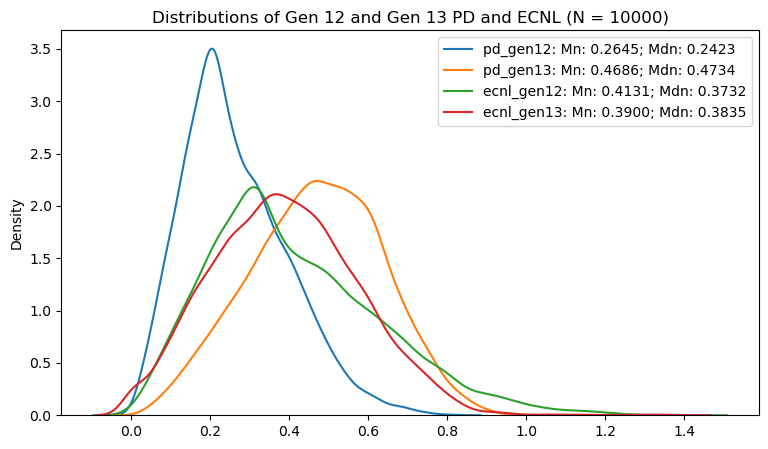

In [12]:
int_nrows = df.shape[0]
list_cols = [
    'pd_gen12',
    'pd_gen13',
    'ecnl_gen12',
    'ecnl_gen13',
]
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Distributions of Gen 12 and Gen 13 PD and ECNL (N = {int_nrows})')
for col in tqdm(list_cols):
    flt_mn = df[col].mean()
    flt_mdn = df[col].median()
    str_label = f'{col}: Mn: {flt_mn:0.4f}; Mdn: {flt_mdn:0.4f}'
    sns.kdeplot(list(df[col]), label=str_label)
# legend
ax.legend()

# save
str_filename = 'plt_distributions.png'
str_local_path =  f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

#### BK vs Non BK Gen 13 ECNL

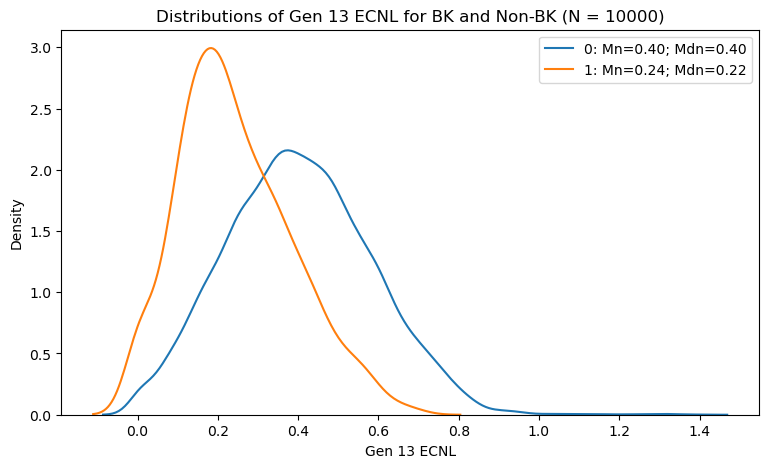

In [13]:
df['ENG-bk'] = df['intopenbktype__app'].apply(
    lambda x: 1 if pd.notnull(x) else 0,
)
list_int_bk = [
    0,
    1,
]
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Distributions of Gen 13 ECNL for BK and Non-BK (N = {int_nrows})')
ax.set_xlabel('Gen 13 ECNL')
for int_bk in list_int_bk:
    df_tmp = df[df['ENG-bk'] == int_bk].copy()
    list_tmp = list(df_tmp['ecnl_gen13'])
    flt_mn = np.mean(list_tmp)
    flt_mdn = np.median(list_tmp)
    str_label = f'{int_bk}: Mn={flt_mn:0.2f}; Mdn={flt_mdn:0.2f}'
    sns.kdeplot(list_tmp, ax=ax, label=str_label)
# legend
plt.legend()

# save
str_filename = 'plt_ecnl_bk_nobk.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

#### Show relationships

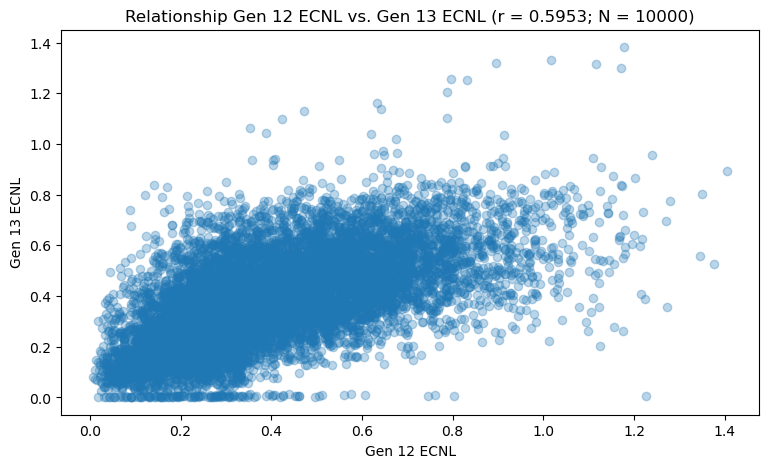

In [14]:
x = df['ecnl_gen12']
y = df['ecnl_gen13']
flt_r = pearsonr(x, y)[0]
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Relationship Gen 12 ECNL vs. Gen 13 ECNL (r = {flt_r:0.4f}; N = {int_nrows})')
ax.set_xlabel('Gen 12 ECNL')
ax.set_ylabel('Gen 13 ECNL')
ax.scatter(x, y, alpha=0.3)

# save
str_filename = 'plt_correlation.png'
str_local_path =  f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

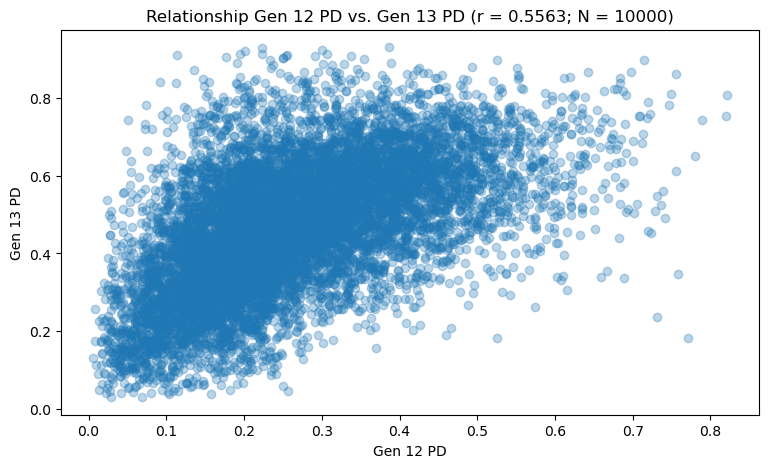

In [15]:
x = df['pd_gen12']
y = df['pd_gen13']
flt_r = pearsonr(x, y)[0]
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Relationship Gen 12 PD vs. Gen 13 PD (r = {flt_r:0.4f}; N = {int_nrows})')
ax.set_xlabel('Gen 12 PD')
ax.set_ylabel('Gen 13 PD')
ax.scatter(x, y, alpha=0.3)

# save
str_filename = 'plt_correlation_pd.png'
str_local_path =  f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

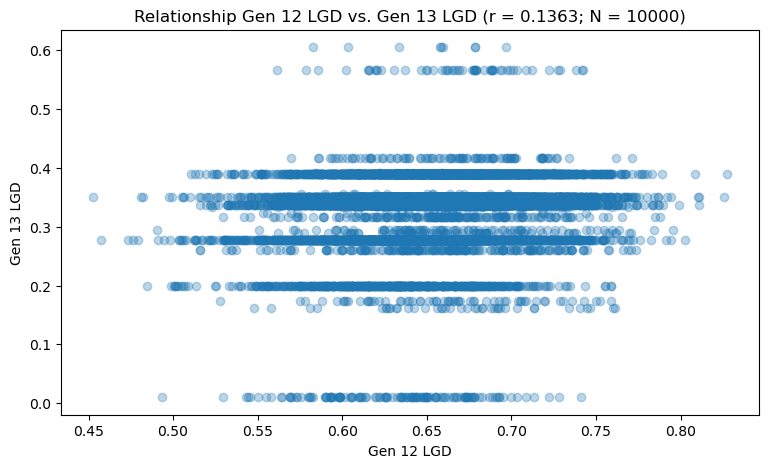

In [16]:
x = df['lgd_gen12']
y = df['lgd_gen13']
flt_r = pearsonr(x, y)[0]
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Relationship Gen 12 LGD vs. Gen 13 LGD (r = {flt_r:0.4f}; N = {int_nrows})')
ax.set_xlabel('Gen 12 LGD')
ax.set_ylabel('Gen 13 LGD')
ax.scatter(x, y, alpha=0.3)

# save
str_filename = 'plt_correlation_lgd.png'
str_local_path =  f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

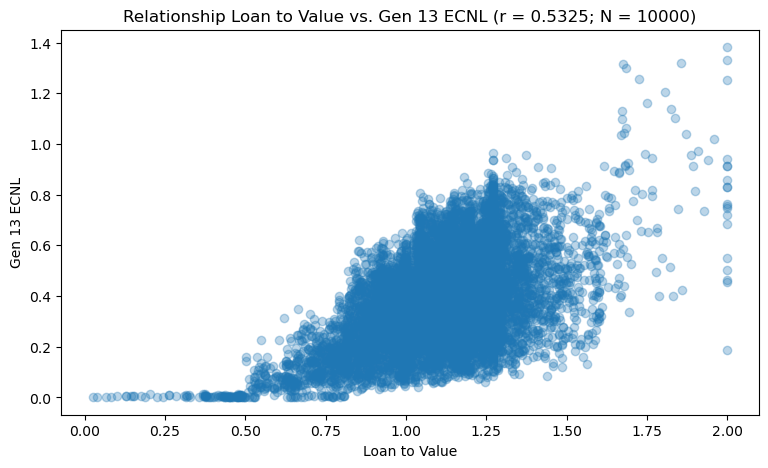

In [17]:
df_tmp = df[df['ENG-loan_to_value'] <= 2.0].copy()
x = df_tmp['ENG-loan_to_value'].fillna(1.27)
y = df_tmp['ecnl_gen13']
flt_r = pearsonr(x, y)[0]
if pd.isnull(flt_r):
    flt_r = spearmanr(x, y)[0]
else:
    pass
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Relationship Loan to Value vs. Gen 13 ECNL (r = {flt_r:0.4f}; N = {int_nrows})')
ax.set_xlabel('Loan to Value')
ax.set_ylabel('Gen 13 ECNL')
ax.scatter(x, y, alpha=0.3)

# save
str_filename = 'plt_correlation_ltv_ecnl.png'
str_local_path =  f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

#### BK

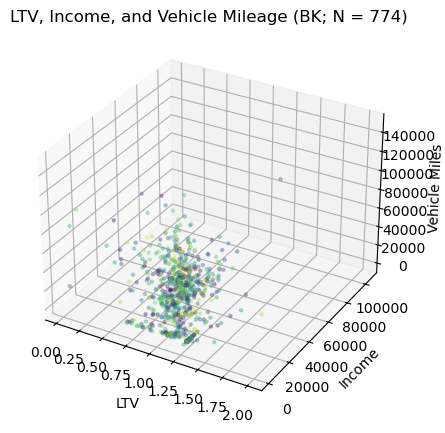

In [18]:
df_tmp = df[df['intopenbktype__app'].isin([7.0, 13.0])].copy()
int_nrows = df_tmp.shape[0]
colors = np.random.rand(int_nrows)
x = df_tmp['ENG-loan_to_value']
y = df_tmp['fltgrossmonthly__income_sum']
z = df_tmp['miles_odometer__app']
# Create figure without an extra 2D subplot
fig = plt.figure(figsize=(9, 5))  # FIX: No plt.subplots()
# Create a 3D subplot
ax = fig.add_subplot(111, projection='3d')
# Set title
ax.set_title(f'LTV, Income, and Vehicle Mileage (BK; N = {int_nrows})')
# Scatter plot
scatter = ax.scatter(x, y, z, c=colors, cmap='viridis', s=5, alpha=0.3)
# Add axis labels
ax.set_xlabel('LTV')
ax.set_ylabel('Income')
ax.set_zlabel('Vehicle Miles')

# save
str_filename = 'plt_ltv_income_miles_bk.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# Show plot
plt.show()

#### No BK

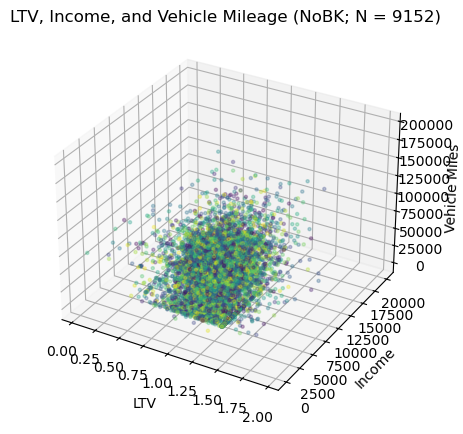

In [19]:
df_tmp = df[~df['intopenbktype__app'].isin([7.0, 13.0])].copy()
df_tmp = df_tmp[df_tmp['ENG-loan_to_value'] < 2].copy()
df_tmp = df_tmp[df_tmp['miles_odometer__app'] < 200000].copy()
df_tmp = df_tmp[df_tmp['fltgrossmonthly__income_sum'] < 20000].copy()
int_nrows = df_tmp.shape[0]
colors = np.random.rand(int_nrows)
x = df_tmp['ENG-loan_to_value']
y = df_tmp['fltgrossmonthly__income_sum']
z = df_tmp['miles_odometer__app']
# Create figure without an extra 2D subplot
fig = plt.figure(figsize=(9, 5))  # FIX: No plt.subplots()
# Create a 3D subplot
ax = fig.add_subplot(111, projection='3d')
# Set title
ax.set_title(f'LTV, Income, and Vehicle Mileage (NoBK; N = {int_nrows})')
# Scatter plot
scatter = ax.scatter(x, y, z, c=colors, cmap='viridis', s=5, alpha=0.3)
# Add axis labels
ax.set_xlabel('LTV')
ax.set_ylabel('Income')
ax.set_zlabel('Vehicle Miles')

# save
str_filename = 'plt_ltv_income_miles_nobk.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# Show plot
plt.show()

#### Analyze PD threshold

In [20]:
# gen 12
int_nrows = df[(df['pd_gen12'] <= flt_threshold_pd) & (df['ecnl_gen12'] <= dict_tiers['D'])].shape[0]
flt_prop = int_nrows / df.shape[0]
print(f'Gen 12 Approvals Considering PD Threshold ({flt_threshold_pd:0.2f}): {flt_prop:0.4f}')

Gen 12 Approvals Considering PD Threshold (0.60): 0.4622


In [21]:
# what prop were declined by pd but approved by ecnl
int_nrows = df[(df['pd_gen12'] > flt_threshold_pd) & (df['ecnl_gen12'] <= dict_tiers['D'])].shape[0]
flt_prop = int_nrows / df.shape[0]
print(f'Gen 12 Approvals Declined by PD Threshold ({flt_threshold_pd:0.2f}): {flt_prop:0.6f}')

Gen 12 Approvals Declined by PD Threshold (0.60): 0.000000


In [22]:
# gen 13
int_nrows = df[(df['pd_gen13'] <= flt_threshold_pd) & (df['ecnl_gen13'] <= dict_tiers['D'])].shape[0]
flt_prop = int_nrows / df.shape[0]
print(f'Gen 13 Approvals Considering PD Threshold ({flt_threshold_pd:0.2f}): {flt_prop:0.4f}')

Gen 13 Approvals Considering PD Threshold (0.60): 0.4230


In [23]:
# what prop were declined by pd but approved by ecnl
int_nrows = df[(df['pd_gen13'] > flt_threshold_pd) & (df['ecnl_gen13'] <= dict_tiers['D'])].shape[0]
flt_prop = int_nrows / df.shape[0]
print(f'Gen 13 Approvals Declined by PD Threshold ({flt_threshold_pd:0.2f}): {flt_prop:0.6f}')

Gen 13 Approvals Declined by PD Threshold (0.60): 0.001800


#### Create tier

In [24]:
# gen 12
df['tier_gen12'] = df['ecnl_gen12'].apply(
    lambda x: get_tier(
        flt_ecnl=x,
        dict_tiers=dict_tiers,
    ),
)
# gen 13
df['tier_gen13'] = df['ecnl_gen13'].apply(
    lambda x: get_tier(
        flt_ecnl=x,
        dict_tiers=dict_tiers,
    ),
)
# show
df

,accountid,pd_gen12,lgd_gen12,ecnl_gen12,request_datetime,pd_gen13,lgd_gen13,ecnl_gen13,intopenbktype__app,ENG-loan_to_value,strdealershiptrackertype__app,fltgrossmonthly__income_sum,miles_odometer__app,ENG-bk,tier_gen12,tier_gen13
0,5782431,0.467144,0.607378,0.669610,2024-12-20 01:09:20+00:00,0.541495,0.390043,0.466545,NaN,1.270000,Franchise,4502.38,77837,0,Decline,Decline
1,8292595,0.337159,0.612115,0.487056,2024-11-28 06:54:03+00:00,0.282371,0.199397,0.159851,NaN,0.501786,Franchise,7056.00,57677,0,Decline,B
2,8300223,0.092892,0.675231,0.148027,2024-12-03 01:52:59+00:00,0.279107,0.172898,0.137006,13.0,0.994140,Franchise,10860.53,42128,1,B,B
3,8303160,0.490566,0.665277,0.770214,2024-11-29 23:18:44+00:00,0.723017,0.350185,0.559286,NaN,1.193988,Independent,3501.31,74484,0,Decline,Decline
4,8306424,0.144040,0.652269,0.221729,2024-12-17 02:28:46+00:00,0.481201,0.350185,0.478411,NaN,1.212453,Independent,11605.52,59650,0,B,Decline
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,8582527,0.553526,0.653014,0.853046,2025-01-21 06:47:43+00:00,0.469815,0.390043,0.404788,NaN,1.318922,Franchise,3587.00,70054,0,Decline,Decline
9996,8582538,0.355347,0.707807,0.593580,2025-01-21 06:50:53+00:00,0.468389,0.277756,0.287381,NaN,0.998997,Independent,3890.00,53654,0,Decline,C
9997,8582546,0.527200,0.651498,0.810588,2025-01-21 06:52:28+00:00,0.714612,0.350185,0.710469,NaN,1.250000,Independent,4100.00,41221,0,Decline,Decline
9998,8582550,0.128649,0.601011,0.182473,2025-01-21 06:53:56+00:00,0.218197,0.277756,0.133875,NaN,0.967072,Franchise,11000.00,154978,0,B,B


#### Tag approved and declined

In [25]:
# gen 12 - approved
df['approved_gen12'] = df['tier_gen12'].apply(
    lambda x: 1 if x != 'Decline' else 0,
)
# gen 13 - approved
df['approved_gen13'] = df['tier_gen13'].apply(
    lambda x: 1 if x != 'Decline' else 0,
)

# gen 12 - declined
df['declined_gen12'] = df['tier_gen12'].apply(
    lambda x: 1 if x == 'Decline' else 0,
)
# gen 13 - declined
df['declined_gen13'] = df['tier_gen13'].apply(
    lambda x: 1 if x == 'Decline' else 0,
)
# approved by both
df['approved_both'] = df.apply(
    lambda x: 1 if (x['tier_gen12'] != 'Decline') and (x['tier_gen13'] != 'Decline') else 0,
    axis=1,
)
# declined by both
df['declined_both'] = df.apply(
    lambda x: 1 if (x['tier_gen12'] == 'Decline') and (x['tier_gen13'] == 'Decline') else 0,
    axis=1,
)
# approved gen 12 - declined gen 13
df['approved_gen12_declined_gen13'] = df.apply(
    lambda x: 1 if (x['tier_gen12'] != 'Decline') and (x['tier_gen13'] == 'Decline') else 0,
    axis=1,
)
# declined gen 12 - approved gen 13
df['declined_gen12_approved_gen13'] = df.apply(
    lambda x: 1 if (x['tier_gen12'] == 'Decline') and (x['tier_gen13'] != 'Decline') else 0,
    axis=1,
)

# reorder
list_cols = [
    'accountid',
    'request_datetime',
]
list_cols_end = [col for col in df.columns if col not in list_cols]
list_cols = list_cols + list_cols_end
df = df[list_cols].copy()

# sort
df.sort_values(by='ecnl_gen12', ascending=True, inplace=True)

# save
str_filename = 'df_swap_in_swap_out.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df.to_csv(str_local_path, index=False)

# show
df

,accountid,request_datetime,pd_gen12,lgd_gen12,ecnl_gen12,pd_gen13,lgd_gen13,ecnl_gen13,intopenbktype__app,ENG-loan_to_value,...,tier_gen12,tier_gen13,approved_gen12,approved_gen13,declined_gen12,declined_gen13,approved_both,declined_both,approved_gen12_declined_gen13,declined_gen12_approved_gen13
7478,8549435,2025-01-09 01:55:05+00:00,0.005697,0.542036,0.007287,0.130503,0.277756,0.080070,NaN,0.989585,...,A1,A,1,1,0,0,1,0,0,0
7960,8556169,2025-01-16 02:48:44+00:00,0.009573,0.490395,0.011079,0.113009,0.293804,0.073343,7.0,1.225165,...,A1,A1,1,1,0,0,1,0,0,0
830,8434345,2024-12-01 00:17:52+00:00,0.008635,0.574852,0.011715,0.175652,0.277756,0.107772,NaN,0.997299,...,A1,A,1,1,0,0,1,0,0,0
2998,8481175,2024-12-18 05:26:04+00:00,0.008775,0.637884,0.013210,0.256152,0.259641,0.146912,13.0,1.086541,...,A1,B,1,1,0,0,1,0,0,0
5626,8525037,2024-12-28 03:24:17+00:00,0.012366,0.544514,0.015891,0.090795,0.337281,0.067646,NaN,1.058541,...,A1,A1,1,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6355,8534301,2025-01-01 02:43:23+00:00,0.691464,0.783871,1.279165,0.808025,0.337281,0.773739,NaN,1.048390,...,Decline,Decline,0,0,1,1,0,1,0,0
3461,8487632,2024-12-14 23:38:00+00:00,0.780458,0.730362,1.345239,0.649699,0.390043,0.559773,NaN,1.265806,...,Decline,Decline,0,0,1,1,0,1,0,0
6414,8535149,2025-01-01 07:03:54+00:00,0.821609,0.695878,1.349304,0.807549,0.350185,0.802867,NaN,1.232035,...,Decline,Decline,0,0,1,1,0,1,0,0
2420,8473850,2024-12-09 23:44:59+00:00,0.755671,0.771268,1.375467,0.611343,0.390043,0.526726,NaN,1.259725,...,Decline,Decline,0,0,1,1,0,1,0,0


#### Rates

100%|██████████| 8/8 [00:00<00:00, 9906.83it/s]


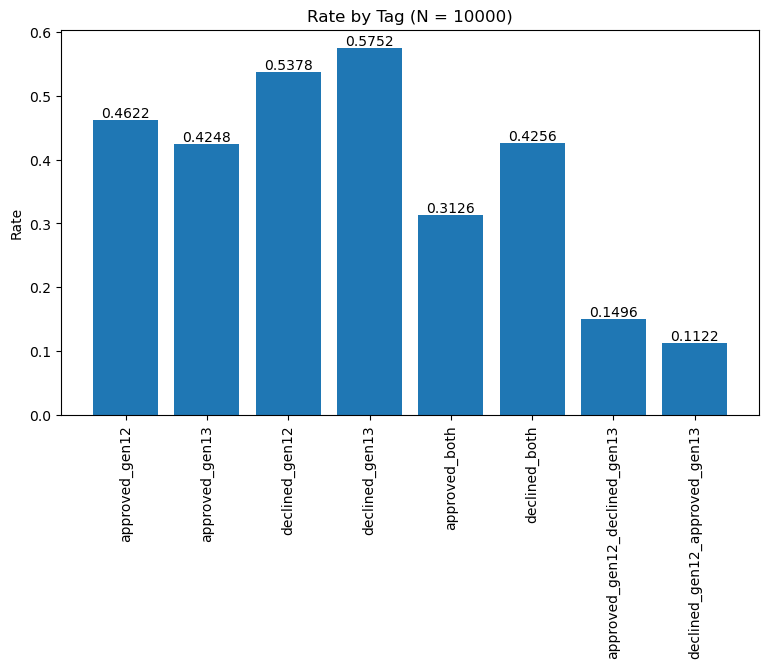

In [26]:
int_nrows = df.shape[0]
list_cols = [
    'approved_gen12',
    'approved_gen13',
    'declined_gen12',
    'declined_gen13',
    'approved_both',
    'declined_both',
    'approved_gen12_declined_gen13',
    'declined_gen12_approved_gen13',
]
list_dict_row = []
for col in tqdm(list_cols):
    # get mean
    flt_mean = df[col].mean()
    # row
    dict_row = {
        'column': col,
        'mean': flt_mean,
    }
    list_dict_row.append(dict_row)
df_tmp = pd.DataFrame(list_dict_row)

# plot
x = df_tmp['column']
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Rate by Tag (N = {int_nrows})')
ax.set_ylabel('Rate')
bars = ax.bar(x, df_tmp['mean'])
ax.set_xticklabels(x, rotation=90)
ax.bar_label(bars, fmt='%.4f')

# save
str_filename = 'plt_swap_in_swap_out.png'
str_local_path =  f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()